# 02 · A vector is just a list of numbers
Level L1 · Part 1 · builds on lesson 01

## Goal
By the end of this lesson you can place recipes as points on a 2-D "sweet vs spicy" map,
store them as vectors, and say what each dimension of a vector means.

## The idea
In lesson 01 we described each recipe by two hand-written scores, (warm, comforting), and that
was enough to find Tomato soup for "something warm for a cold day". That pair of numbers has a name:
a **vector**. A vector is an ordered list of numbers; each position is a **dimension**, and each
dimension stands for one **feature** we chose to measure (warm, comforting, sweet, spicy...).
Because the order is fixed, a vector is also a point: two numbers give a point on a flat map.
Like a theatre ticket "row 3, seat 7": the numbers only work once you know which is the row and
which is the seat.

## Picture

```
 spicy
  1.0 |
  0.8 |                               o Mango salsa
      |
  0.1 |      o Caesar  o Tomato soup
  0.0 |                            Lemon sorbet o       o Brownies
      +-------------------------------------------------------- sweet
       0.0                      0.5                      1.0

  vector = [sweet, spicy]     dimension 0 = sweet, dimension 1 = spicy
```

## Step by step

### 1. One recipe, one vector
We keep the five recipes from lesson 01 and score each one from 0 to 1 on two features:
how **sweet** it tastes and how **spicy** it is. Tomato soup is a little sweet (tomatoes)
and barely spicy. Written as a Python list, the order is the whole meaning: position 0 is sweet,
position 1 is spicy.

In [1]:
FEATURES = ["sweet", "spicy"]      # the meaning of each position, in order
tomato_soup = [0.3, 0.1]

print("vector:", tomato_soup)
print("number of dimensions:", len(tomato_soup))
for position, feature in enumerate(FEATURES):
    print(f"dimension {position} = {feature:5} -> {tomato_soup[position]}")

vector: [0.3, 0.1]
number of dimensions: 2
dimension 0 = sweet -> 0.3
dimension 1 = spicy -> 0.1


`len(tomato_soup)` is 2, so this is a **2-dimensional** (2-D) vector. Reading `tomato_soup[1]`
only makes sense because `FEATURES[1]` tells us it is "spicy".

### 2. All five recipes
Every recipe gets a vector with the **same features in the same order**. That shared order is what
makes vectors comparable: dimension 0 is always sweetness, for every recipe.

In [2]:
recipe_vectors = {          # [sweet, spicy], scored by hand from 0 to 1
    "Tomato soup":        [0.3, 0.1],
    "Mango salsa":        [0.6, 0.8],
    "Chocolate brownies": [0.95, 0.0],
    "Caesar salad":       [0.1, 0.1],
    "Lemon sorbet":       [0.8, 0.0],
}
print(f"{'recipe':20} {'sweet':>6} {'spicy':>6}")
for name, (sweet, spicy) in recipe_vectors.items():
    print(f"{name:20} {sweet:6.2f} {spicy:6.2f}")

recipe                sweet  spicy
Tomato soup            0.30   0.10
Mango salsa            0.60   0.80
Chocolate brownies     0.95   0.00
Caesar salad           0.10   0.10
Lemon sorbet           0.80   0.00


### 3. Vectors are points: draw the map
A 2-D vector `[x, y]` is a point on a flat map. We put sweetness on the horizontal axis and
spiciness on the vertical axis, and label each point with its recipe name.

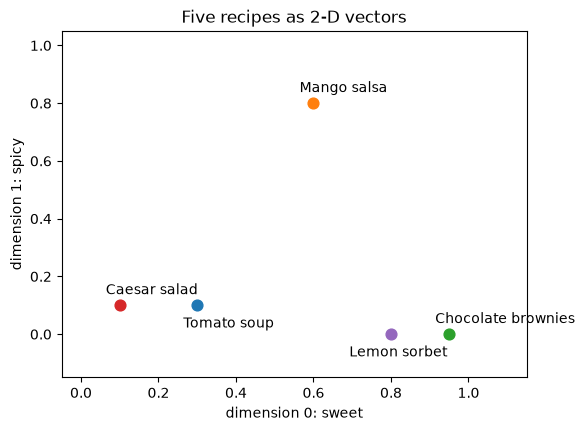

In [3]:
import matplotlib.pyplot as plt

label_offset = {"Tomato soup": (-10, -16), "Lemon sorbet": (-30, -16)}  # move labels apart
fig, ax = plt.subplots(figsize=(6, 4.5))
for name, (sweet, spicy) in recipe_vectors.items():
    ax.scatter(sweet, spicy, s=60)
    ax.annotate(name, (sweet, spicy), textcoords="offset points",
                xytext=label_offset.get(name, (-10, 8)))
ax.set_xlabel("dimension 0: sweet")
ax.set_ylabel("dimension 1: spicy")
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.15, 1.05)
ax.set_title("Five recipes as 2-D vectors")
plt.show()

Things you can read straight off the map: the two desserts (brownies, sorbet) sit together at
the bottom right (sweet, not spicy). Mango salsa is alone at the top: the only spicy dish.
Soup and salad sit near the bottom left (neither sweet nor spicy). **Recipes that taste alike
end up close together.** That is the whole trick behind vector search; lesson 03 turns
"close" into a number.

### 4. Many vectors in one NumPy array
Real systems keep vectors in a **matrix**: one row per recipe, one column per dimension.
NumPy stores this as a 2-D array whose `shape` is `(number of vectors, number of dimensions)`.
We keep the names in a separate list in the same order, so row `i` belongs to `names[i]`.

In [4]:
import numpy as np

names = list(recipe_vectors)
vectors = np.array([recipe_vectors[n] for n in names], dtype=np.float32)

print("shape:", vectors.shape, "->", vectors.shape[0], "recipes,", vectors.shape[1], "dimensions")
print("dtype:", vectors.dtype)
print(vectors)

shape: (5, 2) -> 5 recipes, 2 dimensions
dtype: float32
[[0.3  0.1 ]
 [0.6  0.8 ]
 [0.95 0.  ]
 [0.1  0.1 ]
 [0.8  0.  ]]


`float32` (4 bytes per number) is the type almost every vector database uses by default,
so we use it from the start.

### 5. Read one dimension across all recipes
A row is one recipe's vector. A **column** is one feature across every recipe:
`vectors[:, 0]` is all the sweetness scores. `argmax` gives the row with the biggest value,
which answers "which recipe is sweetest?" without writing a loop.

In [5]:
sweet_column = vectors[:, FEATURES.index("sweet")]
print("sweet scores:", sweet_column)
print("sweetest recipe:", names[int(np.argmax(sweet_column))])

print("row for Mango salsa:", vectors[names.index("Mango salsa")])

sweet scores: [0.3  0.6  0.95 0.1  0.8 ]
sweetest recipe: Chocolate brownies
row for Mango salsa: [0.6 0.8]


### 6. More features = more dimensions
Two features cannot tell everything apart: Tomato soup `[0.3, 0.1]` and Caesar salad `[0.1, 0.1]`
are neighbours on the sweet/spicy map, yet one is hot and one is cold. Lesson 01 had exactly the
feature we are missing: **warm**. Adding it as a third column makes every vector 3-D.

In [6]:
FEATURES_3D = ["sweet", "spicy", "warm"]
warm = {"Tomato soup": 0.9, "Mango salsa": 0.1, "Chocolate brownies": 0.4,
        "Caesar salad": 0.1, "Lemon sorbet": 0.0}        # the "warm" scores from lesson 01

warm_column = np.array([[warm[n]] for n in names], dtype=np.float32)
vectors_3d = np.hstack([vectors, warm_column])
print("shape:", vectors_3d.shape)
for name, row in zip(names, vectors_3d, strict=True):
    print(f"{name:20} {row}")

shape: (5, 3)
Tomato soup          [0.3 0.1 0.9]
Mango salsa          [0.6 0.8 0.1]
Chocolate brownies   [0.95 0.   0.4 ]
Caesar salad         [0.1 0.1 0.1]
Lemon sorbet         [0.8 0.  0. ]


Now soup `[0.3, 0.1, 0.9]` and salad `[0.1, 0.1, 0.1]` differ clearly in dimension 2.
We cannot draw a 3-D map on a flat page as easily, and nobody can picture 384 dimensions,
but the arithmetic is identical. Lesson 05 lets a model write vectors with hundreds of
dimensions; nobody names those features by hand, yet the rule stays the same:
one position, one meaning, same order for every vector.

## What just happened
- Tomato soup became `[0.3, 0.1]`; `FEATURES` says position 0 is sweet, 1 is spicy (step 1).
- Same features, same order for all five, so they share one map: desserts together, Mango salsa alone (steps 2–3).
- Stacked vectors form a `(5, 2)` NumPy matrix: rows are recipes, columns dimensions (step 4).
- One column answers one feature question: Chocolate brownies is the sweetest (step 5).
- Adding "warm" grew the shape to `(5, 3)` and separated soup from salad (step 6).

## Common mistakes

**1. Vectors of different lengths.** If one recipe forgets a feature, the vectors no longer line up.
NumPy refuses to build a matrix from them:

In [7]:
try:
    broken = {
        "Tomato soup": [0.3, 0.1],
        "Mango salsa": [0.6],            # forgot the spicy score
    }
    np.array(list(broken.values()), dtype=np.float32)
except Exception as err:  # this mistake is on purpose: show the error, keep the notebook running
    print(f"{type(err).__name__}: {err}")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.


Fix: check every vector's length first, so the error names the bad recipe:

In [8]:
def check_dimensions(vectors_by_name, features):
    for name, vec in vectors_by_name.items():
        if len(vec) != len(features):
            raise ValueError(f"{name} has {len(vec)} values, expected {len(features)} ({features})")
    return np.array(list(vectors_by_name.values()), dtype=np.float32)

print("check passes for the five recipes:", check_dimensions(recipe_vectors, FEATURES).shape)

check passes for the five recipes: (5, 2)


Now run the same check on the `broken` dictionary:

In [9]:
try:
    check_dimensions(broken, FEATURES)
except Exception as err:  # this mistake is on purpose: show the error, keep the notebook running
    print(f"{type(err).__name__}: {err}")

ValueError: Mango salsa has 1 values, expected 2 (['sweet', 'spicy'])


The message points straight at Mango salsa. Add the missing spicy score and the check passes:

In [10]:
broken["Mango salsa"] = [0.6, 0.8]
fixed_matrix = check_dimensions(broken, FEATURES)
print("fixed shape:", fixed_matrix.shape)

fixed shape: (2, 2)


**2. Asking for a dimension that does not exist.** Positions start at 0, so a 2-D vector has
dimensions 0 and 1 only. Asking the 2-D matrix for the "warm" column (position 2) fails:

In [11]:
try:
    print("vectors shape:", vectors.shape)
    warm_position = FEATURES_3D.index("warm")   # 2
    vectors[:, warm_position]
except Exception as err:  # this mistake is on purpose: show the error, keep the notebook running
    print(f"{type(err).__name__}: {err}")

vectors shape: (5, 2)
IndexError: index 2 is out of bounds for axis 1 with size 2


Fix: look positions up in the feature list that belongs to *this* matrix, and check the shape.
`vectors` has 2 columns; the warm scores live in `vectors_3d`.

In [12]:
warm_position = FEATURES_3D.index("warm")
print("vectors:", vectors.shape, " vectors_3d:", vectors_3d.shape)
print("warm column:", vectors_3d[:, warm_position])

vectors: (5, 2)  vectors_3d: (5, 3)
warm column: [0.9 0.1 0.4 0.1 0. ]


A quieter version of the same bug: writing one recipe as `[spicy, sweet]` instead of
`[sweet, spicy]`. Nothing crashes, the recipe just lands in the wrong place on the map.
Keeping one `FEATURES` list and building every vector from it is the defence.

## Try it
1. Add `"Thai green curry"` with your own `[sweet, spicy]` scores (it is very spicy and a little
   sweet). Rebuild `names` and `vectors`, print the new shape, and redraw the map. Which recipe
   sits closest to the curry by eye?
2. Using a column of `vectors_3d`, print the name of the **spiciest** recipe and the name of the
   **least warm** recipe (hint: `np.argmax`, `np.argmin`). Use the original five recipes:
   `list(warm)` gives their names in row order.

In [13]:
# your code here

## Key terms
- **vector** — an ordered list of numbers; in a vector database, one item's description as numbers.
- **dimension** — one position in a vector; a 2-D vector has two, an embedding may have hundreds.
- **feature** — the property a dimension measures, such as "sweet" or "spicy".
- **shape** — the size of a NumPy array per axis; `(5, 2)` means 5 vectors of 2 dimensions each.